# Steam Game Market Analysis - Database Edition

This notebook performs comprehensive analysis of Steam game market data using Postgres database operations.

**Features:**
- Memory-efficient database queries for large-scale data (50M+ reviews)
- Interactive visualizations and market insights
- Genre-based filtering and analysis
- User behavior and game popularity metrics
- Market concentration analysis

**Prerequisites:**
- Run the database assembler first: `cd graph-analyser/assemble-graph-database && make run`
- Ensure `steam_reviews.db` exists in the working directory or specify the path below

## Import Required Libraries

Import necessary libraries for database operations, data analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
import os
from pathlib import Path
from typing import List, Dict, Tuple, Optional

# PostgreSQL imports
try:
    import psycopg2
    from sqlalchemy import create_engine, text
    print("✓ PostgreSQL drivers loaded successfully")
except ImportError as e:
    print("❌ PostgreSQL dependencies missing. Please install:")
    print("   pip install psycopg2-binary sqlalchemy")
    raise e
  
# Load environment variables from .env file
from dotenv import load_dotenv

env_file = Path("assemble-graph-database/.env")
if env_file.exists():
    load_dotenv(env_file)
    print(f"✓ Loaded environment variables from {env_file}")
else:
    print(f"⚠️  .env file not found at {env_file}")
    print("💡 Using default values")

# Configure display settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✓ Libraries imported successfully")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Numpy version: {np.__version__}")

output_dir = Path("analysis_plots")
output_dir.mkdir(exist_ok=True)

✓ PostgreSQL drivers loaded successfully
✓ Loaded environment variables from assemble-graph-database/.env
✓ Libraries imported successfully
✓ Pandas version: 2.3.2
✓ Numpy version: 2.3.2


## Database Connection Setup

Connect to the Steam reviews SQLite database and verify its structure.

In [2]:
# PostgreSQL Database connection configuration

# Database connection parameters
DB_HOST = os.getenv('DB_HOST', '127.0.0.1')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_USER = os.getenv('DB_USER', 'postgres')
DB_PASSWORD = os.getenv('DB_PASSWORD', 'postgres')
DB_NAME = os.getenv('DB_NAME', 'steam_reviews')
DB_SSLMODE = os.getenv('DB_SSLMODE', 'disable')

# PostgreSQL connection string
connection_string = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode={DB_SSLMODE}"

print(f"🐘 Connecting to PostgreSQL database:")
print(f"   Host: {DB_HOST}:{DB_PORT}")
print(f"   Database: {DB_NAME}")
print(f"   User: {DB_USER}")

# Connect to database
try:
    # Create SQLAlchemy engine for pandas integration
    engine = create_engine(connection_string)
    
    # Test connection with direct psycopg2
    conn = psycopg2.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USER,
        password=DB_PASSWORD,
        database=DB_NAME
    )
    
    print(f"✓ Connected to PostgreSQL database: {DB_HOST}:{DB_PORT}/{DB_NAME}")
    
    # Get database size information
    cursor = conn.cursor()
    cursor.execute("""
        SELECT pg_size_pretty(pg_database_size(%s)) as db_size;
    """, (DB_NAME,))
    db_size = cursor.fetchone()[0]
    print(f"✓ Database size: {db_size}")
    cursor.close()
    
    # For pandas compatibility, we'll use the engine for pd.read_sql_query
    # Note: conn is psycopg2 connection, engine is SQLAlchemy engine
    
except Exception as e:
    print(f"❌ Database connection failed: {e}")
    print(f"💡 Make sure PostgreSQL is running and the database exists.")
    print(f"💡 Run: cd graph-analyser/assemble-graph-database && docker compose --env-file assemble-graph-database/.env up -d")
    raise

🐘 Connecting to PostgreSQL database:
   Host: 127.0.0.1:25432
   Database: steam_reviews
   User: postgres
✓ Connected to PostgreSQL database: 127.0.0.1:25432/steam_reviews
✓ Database size: 27 GB


## Database Schema Overview

Explore the database structure and verify data integrity.

In [3]:
# Check database tables and their structure
tables_query = """
    SELECT table_name as name 
    FROM information_schema.tables 
    WHERE table_schema = 'public' AND table_type = 'BASE TABLE'
"""
tables = pd.read_sql_query(tables_query, engine)
print("📋 Database Tables:")
print(tables)

# Check table schemas
for table in tables['name'].values:
    print(f"\n📊 Table: {table}")
    schema_query = f"""
        SELECT column_name, data_type, is_nullable, column_default
        FROM information_schema.columns 
        WHERE table_name = '{table}' AND table_schema = 'public'
        ORDER BY ordinal_position
    """
    schema = pd.read_sql_query(schema_query, engine)
    print(schema.to_string(index=False))

📋 Database Tables:
                    name
0             categories
1                reviews
2                  games
3  user_game_connections
4        game_categories
5            game_genres
6                 genres
7       graph_statistics
8                  users
9  game_projection_edges

📊 Table: categories
column_name                   data_type is_nullable    column_default
         id                     integer          NO              None
       name                        text          NO              None
 created_at timestamp without time zone         YES CURRENT_TIMESTAMP

📊 Table: reviews
      column_name                   data_type is_nullable    column_default
        review_id           character varying          NO              None
          game_id           character varying          NO              None
          user_id           character varying          NO              None
         voted_up                     boolean          NO              None
receive

In [ ]:
# Get basic statistics for each table
print("\n📈 Table Row Counts:")
stats = {}
for table in tables['name'].values:
    count_query = f"SELECT COUNT(*) as count FROM {table}"
    count = pd.read_sql_query(count_query, engine).iloc[0, 0]
    stats[table] = count
    print(f"   {table}: {count:,} rows")

# Display statistics as DataFrame for better formatting
stats_df = pd.DataFrame(list(stats.items()), columns=['Table', 'Row Count'])
print("\n📊 Summary:")
print(stats_df.to_string(index=False))

# Graph measures analysis

Count the number of components in the graph, number of game nodes, number of players nodes, number of edges.

In [ ]:
# Graph Statistics - General Overview
print("📊 Computing Graph Statistics")
print("=" * 60)

# Import text for SQLAlchemy 2.0+
from sqlalchemy import text

# Create table to store graph statistics if it doesn't exist
print("🔧 Creating graph_statistics table...")

create_stats_table = """
  CREATE TABLE IF NOT EXISTS graph_statistics (
      id SERIAL PRIMARY KEY,
      statistic_name VARCHAR(255) UNIQUE NOT NULL,
      statistic_value NUMERIC,
      statistic_type VARCHAR(50),
      description TEXT,
      computed_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
      updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
  );
"""

with engine.begin() as connection:
    connection.execute(text(create_stats_table))

print("✓ Graph statistics table created (if not existed)")

# Count nodes and edges
graph_stats_query = """
SELECT 
    'Games' as node_type,
    COUNT(*) as node_count
FROM games
UNION ALL
SELECT 
    'Users' as node_type,
    COUNT(*) as node_count
FROM users
UNION ALL
SELECT 
    'Reviews (Edges)' as node_type,
    COUNT(*) as node_count
FROM reviews
"""

graph_stats = pd.read_sql_query(graph_stats_query, engine)
print("\n🎮 Graph Structure:")
print(graph_stats.to_string(index=False))

# Additional edge statistics
edge_stats_query = """
SELECT 
    (SELECT COUNT(DISTINCT game_id) FROM reviews) as games_with_reviews,
    (SELECT COUNT(DISTINCT user_id) FROM reviews) as active_users,
    (SELECT COUNT(*) FROM reviews) as total_edges,
    (SELECT AVG(cnt) FROM (
        SELECT COUNT(*) as cnt FROM reviews GROUP BY game_id
    ) g) as avg_edges_per_game,
    (SELECT AVG(cnt) FROM (
        SELECT COUNT(*) as cnt FROM reviews GROUP BY user_id
    ) u) as avg_edges_per_user
"""

edge_stats = pd.read_sql_query(edge_stats_query, engine)
print("\n📈 Edge Statistics:")
for col in edge_stats.columns:
    value = edge_stats[col].iloc[0]
    print(f"   {col.replace('_', ' ').title():<30} {value:,.2f}")

# Store statistics in the database
print("\n💾 Storing statistics in database...")

# Prepare statistics to insert
stats_to_insert = []

# Node counts
for _, row in graph_stats.iterrows():
    stats_to_insert.append({
        'name': row['node_type'],
        'value': row['node_count'],
        'type': 'node_count',
        'description': f"Total number of {row['node_type']} nodes in the graph"
    })

# Edge statistics
for col in edge_stats.columns:
    value = edge_stats[col].iloc[0]
    stats_to_insert.append({
        'name': col,
        'value': float(value),
        'type': 'edge_statistic',
        'description': f"{col.replace('_', ' ').title()} in the graph"
    })

# Insert or update statistics
with engine.begin() as connection:
    for stat in stats_to_insert:
        upsert_query = """
        INSERT INTO graph_statistics (statistic_name, statistic_value, statistic_type, description, updated_at)
        VALUES (:name, :value, :type, :description, CURRENT_TIMESTAMP)
        ON CONFLICT (statistic_name) 
        DO UPDATE SET 
            statistic_value = EXCLUDED.statistic_value,
            statistic_type = EXCLUDED.statistic_type,
            description = EXCLUDED.description,
            updated_at = CURRENT_TIMESTAMP
        """
        connection.execute(text(upsert_query), stat)

print("✓ Statistics stored in graph_statistics table")

# Display stored statistics
stored_stats_query = """
SELECT 
    statistic_name,
    statistic_value,
    statistic_type,
    updated_at
FROM graph_statistics
ORDER BY 
    CASE statistic_type
        WHEN 'node_count' THEN 1
        WHEN 'edge_statistic' THEN 2
        ELSE 3
    END,
    statistic_name
"""

stored_stats = pd.read_sql_query(stored_stats_query, engine)
print("\n📊 Stored Graph Statistics:")
print(stored_stats.to_string(index=False))

print(f"\n✅ Graph statistics computed and stored successfully")

📊 Computing Graph Statistics
🔧 Creating graph_statistics table...
✓ Graph statistics table created (if not existed)

🎮 Graph Structure:
      node_type  node_count
          Games       98101
          Users    22118178
Reviews (Edges)    51091026

📈 Edge Statistics:
   Games With Reviews             32,970.00
   Active Users                   22,118,178.00
   Total Edges                    51,091,026.00
   Avg Edges Per Game             1,549.62
   Avg Edges Per User             2.31

💾 Storing statistics in database...
✓ Statistics stored in graph_statistics table

📊 Stored Graph Statistics:
    statistic_name  statistic_value statistic_type                 updated_at
             Games     9.810100e+04     node_count 2025-11-02 19:43:45.723712
   Reviews (Edges)     5.109103e+07     node_count 2025-11-02 19:43:45.723712
             Users     2.211818e+07     node_count 2025-11-02 19:43:45.723712
      active_users     2.211818e+07 edge_statistic 2025-11-02 19:43:45.723712
avg_edges

### Connected Components Analysis

Identify and analyze connected components in the bipartite graph. Add component_id column to track which component each node belongs to.

## Correlation between centrality indicators and game success (nº of reviews)

Compute
- Degree centrality: identify popular games and very active players
- Harmonic centrality (in place of closeness since the graph isn't connected): identify ecletic players and popular games
- Betweenness centrality: identify players and games that connects different clusters
- Eigenvector centrality: identify "influential" games
- Cross-Clique centrality: identify "influential" games and players belonging to different groups
- Freeman Centralization: measure how centralized the network is on the most central game

#### Correlation between degree centrality and game success

Clearly, if we consider success a bigger number of reviews, than a game degree is correlated to the games review count with a correlation coefficient of 1.

### Freeman centralization using degree centrality

$C_x = \frac{\sum^{N}_{i=1} C_x(p_*) - C_x(p_i)}{\max \sum^{N}_{i=1} C_x(p_*) - C_x(p_i)}$

📊 Computing Freeman Centralization Metric

🎮 Computing Freeman Centralization for Games...


   Maximum game degree: 840,001
   Sum of differences: 82,353,847,075
   Number of game nodes: 98,101
   Theoretical maximum sum: 2,169,793,261,800
   Freeman Centralization (Games): 0.037955

👥 Computing Freeman Centralization for Users...
   Maximum user degree: 4,116
   Sum of differences: 90,987,329,622
   Number of user nodes: 22,118,178
   Theoretical maximum sum: 2,169,815,281,877
   Freeman Centralization (Users): 0.041933

📋 Freeman Centralization Summary:
------------------------------------------------------------
   Games:  0.037955
   Users:  0.041933

💡 Interpretation:
   - Values close to 0: Decentralized network (all nodes similar degree)
   - Values close to 1: Centralized network (star-like structure)

💾 Storing Freeman Centralization metrics in database...
✓ Freeman Centralization metrics stored in graph_statistics table

📊 Creating Freeman Centralization visualization...
   Maximum user degree: 4,116
   Sum of differences: 90,987,329,622
   Number of user nodes: 22,

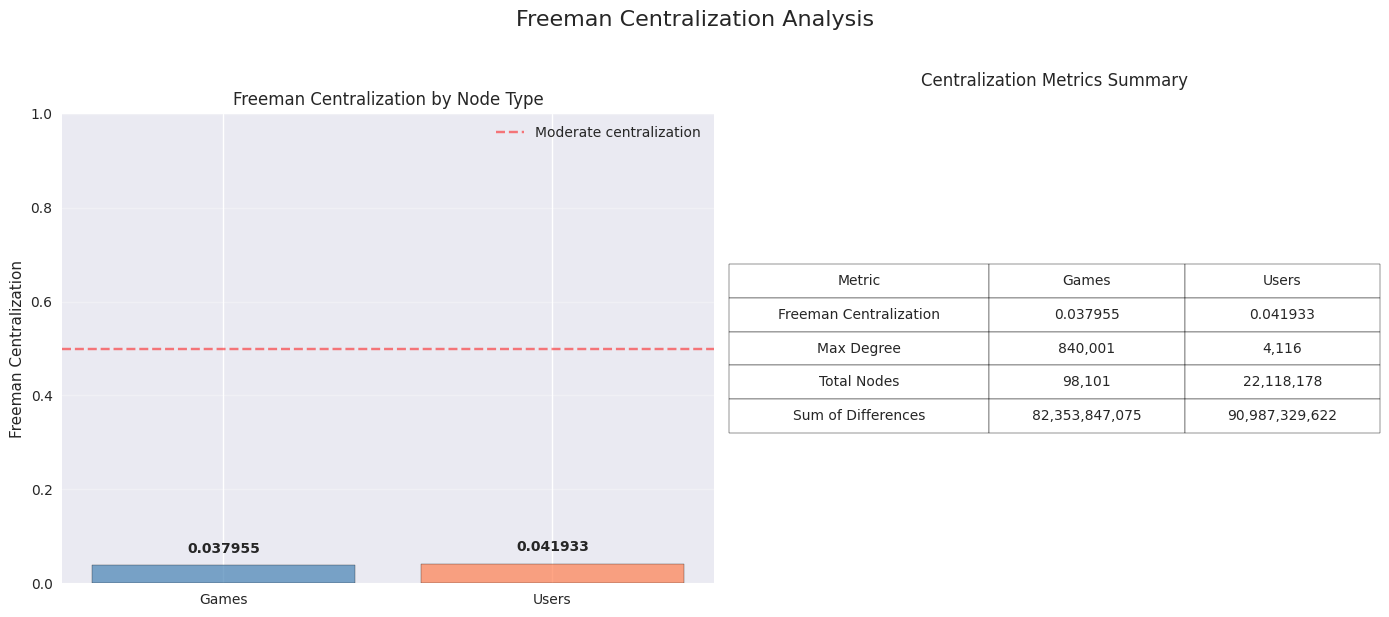

📊 Freeman Centralization plot saved to analysis_plots/freeman_centralization.png

✅ Freeman Centralization computation complete!


<Figure size 800x550 with 0 Axes>

In [7]:
# Freeman Centralization using Degree Centrality
print("📊 Computing Freeman Centralization Metric")
print("=" * 60)

# Freeman Centralization formula:
# C_x = Σ(C_x(p*) - C_x(p_i)) / max(Σ(C_x(p*) - C_x(p_i)))
# 
# Where:
# - C_x(p*) = maximum centrality (degree) in the network
# - C_x(p_i) = centrality (degree) of node i
# - Numerator = sum of differences from max degree
# - Denominator = theoretical maximum sum of differences (star network)

# Compute Freeman Centralization for Games
print("\n🎮 Computing Freeman Centralization for Games...")

# First get the max degree
max_degree_query = "SELECT MAX(degree) as max_degree, COUNT(*) as total_nodes FROM games"
max_degree_data = pd.read_sql_query(max_degree_query, engine)
max_degree_games = max_degree_data['max_degree'].iloc[0]
n_games = max_degree_data['total_nodes'].iloc[0]

# Then compute sum of differences using the max degree
sum_diff_query = f"""
SELECT SUM({max_degree_games} - degree) as sum_differences
FROM games
"""
sum_diff_data = pd.read_sql_query(sum_diff_query, engine)
sum_diff_games = sum_diff_data['sum_differences'].iloc[0]

# For a bipartite graph, the maximum possible degree for a game node is the number of users
n_users_query = "SELECT COUNT(*) as count FROM users"
n_users = pd.read_sql_query(n_users_query, engine)['count'].iloc[0]

# Theoretical maximum: star network where one node connects to all users
# and all other nodes have degree 0
max_sum_diff_games = (n_games - 1) * n_users

# Freeman Centralization for games
freeman_centralization_games = sum_diff_games / max_sum_diff_games if max_sum_diff_games > 0 else 0

print(f"   Maximum game degree: {max_degree_games:,}")
print(f"   Sum of differences: {sum_diff_games:,}")
print(f"   Number of game nodes: {n_games:,}")
print(f"   Theoretical maximum sum: {max_sum_diff_games:,}")
print(f"   Freeman Centralization (Games): {freeman_centralization_games:.6f}")

# Compute Freeman Centralization for Users
print("\n👥 Computing Freeman Centralization for Users...")

# First get the max degree
max_degree_user_query = "SELECT MAX(degree) as max_degree, COUNT(*) as total_nodes FROM users"
max_degree_user_data = pd.read_sql_query(max_degree_user_query, engine)
max_degree_users = max_degree_user_data['max_degree'].iloc[0]
n_users_actual = max_degree_user_data['total_nodes'].iloc[0]

# Then compute sum of differences using the max degree
sum_diff_user_query = f"""
SELECT SUM({max_degree_users} - degree) as sum_differences
FROM users
"""
sum_diff_user_data = pd.read_sql_query(sum_diff_user_query, engine)
sum_diff_users = sum_diff_user_data['sum_differences'].iloc[0]

# For a bipartite graph, the maximum possible degree for a user node is the number of games
n_games_query = "SELECT COUNT(*) as count FROM games"
n_games_actual = pd.read_sql_query(n_games_query, engine)['count'].iloc[0]

# Theoretical maximum: star network where one user connects to all games
# and all other users have degree 0
max_sum_diff_users = (n_users_actual - 1) * n_games_actual

# Freeman Centralization for users
freeman_centralization_users = sum_diff_users / max_sum_diff_users if max_sum_diff_users > 0 else 0

print(f"   Maximum user degree: {max_degree_users:,}")
print(f"   Sum of differences: {sum_diff_users:,}")
print(f"   Number of user nodes: {n_users_actual:,}")
print(f"   Theoretical maximum sum: {max_sum_diff_users:,}")
print(f"   Freeman Centralization (Users): {freeman_centralization_users:.6f}")

# Summary
print("\n📋 Freeman Centralization Summary:")
print("-" * 60)
print(f"   Games:  {freeman_centralization_games:.6f}")
print(f"   Users:  {freeman_centralization_users:.6f}")
print("\n💡 Interpretation:")
print("   - Values close to 0: Decentralized network (all nodes similar degree)")
print("   - Values close to 1: Centralized network (star-like structure)")

# Store Freeman Centralization metrics in database
print("\n💾 Storing Freeman Centralization metrics in database...")

freeman_stats = [
    {
        'name': 'freeman_centralization_games',
        'value': float(freeman_centralization_games),
        'type': 'centralization_metric',
        'description': 'Freeman Centralization for game nodes using degree centrality'
    },
    {
        'name': 'freeman_centralization_users',
        'value': float(freeman_centralization_users),
        'type': 'centralization_metric',
        'description': 'Freeman Centralization for user nodes using degree centrality'
    },
    {
        'name': 'max_degree_games',
        'value': float(max_degree_games),
        'type': 'centralization_metric',
        'description': 'Maximum degree among game nodes'
    },
    {
        'name': 'max_degree_users',
        'value': float(max_degree_users),
        'type': 'centralization_metric',
        'description': 'Maximum degree among user nodes'
    }
]

with engine.begin() as connection:
    for stat in freeman_stats:
        upsert_query = """
        INSERT INTO graph_statistics (statistic_name, statistic_value, statistic_type, description, updated_at)
        VALUES (:name, :value, :type, :description, CURRENT_TIMESTAMP)
        ON CONFLICT (statistic_name) 
        DO UPDATE SET 
            statistic_value = EXCLUDED.statistic_value,
            statistic_type = EXCLUDED.statistic_type,
            description = EXCLUDED.description,
            updated_at = CURRENT_TIMESTAMP
        """
        connection.execute(text(upsert_query), stat)

print("✓ Freeman Centralization metrics stored in graph_statistics table")

# Create visualization
print("\n📊 Creating Freeman Centralization visualization...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Freeman Centralization Analysis', fontsize=16, y=1.02)

# Bar chart comparing centralization
metrics = ['Games', 'Users']
values = [freeman_centralization_games, freeman_centralization_users]
colors_bar = ['steelblue', 'coral']

ax1.bar(metrics, values, color=colors_bar, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Freeman Centralization')
ax1.set_title('Freeman Centralization by Node Type')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Moderate centralization')
ax1.legend()

# Add values on bars
for i, v in enumerate(values):
    ax1.text(i, v + 0.02, f'{v:.6f}', ha='center', va='bottom', fontweight='bold')

# Summary table
summary_data = [
    ['Metric', 'Games', 'Users'],
    ['Freeman Centralization', f'{freeman_centralization_games:.6f}', f'{freeman_centralization_users:.6f}'],
    ['Max Degree', f'{max_degree_games:,}', f'{max_degree_users:,}'],
    ['Total Nodes', f'{n_games:,}', f'{n_users_actual:,}'],
    ['Sum of Differences', f'{sum_diff_games:,}', f'{sum_diff_users:,}']
]

ax2.axis('tight')
ax2.axis('off')
table = ax2.table(cellText=summary_data[1:], colLabels=summary_data[0],
                  cellLoc='center', loc='center',
                  colWidths=[0.4, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax2.set_title('Centralization Metrics Summary', pad=20)

plt.tight_layout()
plt.show()

# Save plot
plt.savefig(output_dir / 'freeman_centralization.png', dpi=300, bbox_inches='tight')
print(f"📊 Freeman Centralization plot saved to {output_dir / 'freeman_centralization.png'}")

print("\n✅ Freeman Centralization computation complete!")

## One-Mode Projection: Game-to-Game Network

Create a projection of the bipartite graph where:
- **Nodes**: Only games (removing users)
- **Edges**: Connect two games if they share at least one player/reviewer
- **Edge Weight**: Number of players who reviewed both games (shared audience strength)

This projection reveals game similarity and market overlap based on player behavior.

### Create Projection Table

Create a table to store the one-mode projection edges with weights.

In [3]:
# Create table for one-mode projection
print("🔧 Creating game_projection_edges table...")
print("=" * 60)

create_projection_table = """
CREATE TABLE IF NOT EXISTS game_projection_edges (
    id SERIAL PRIMARY KEY,
    game_id_1 VARCHAR(255) NOT NULL,
    game_id_2 VARCHAR(255) NOT NULL,
    weight INTEGER NOT NULL,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    CONSTRAINT game_projection_unique UNIQUE (game_id_1, game_id_2),
    CONSTRAINT game_projection_ordered CHECK (game_id_1 < game_id_2),
    FOREIGN KEY (game_id_1) REFERENCES games(game_id) ON DELETE CASCADE,
    FOREIGN KEY (game_id_2) REFERENCES games(game_id) ON DELETE CASCADE
);
"""

with engine.begin() as connection:
    connection.execute(text(create_projection_table))

print("✓ game_projection_edges table created (if not existed)")

# Create indexes for better query performance
print("\n🔧 Creating indexes on projection table...")

create_indexes = [
    "CREATE INDEX IF NOT EXISTS idx_game_proj_game1 ON game_projection_edges(game_id_1);",
    "CREATE INDEX IF NOT EXISTS idx_game_proj_game2 ON game_projection_edges(game_id_2);",
    "CREATE INDEX IF NOT EXISTS idx_game_proj_weight ON game_projection_edges(weight DESC);"
]

with engine.begin() as connection:
    for idx_query in create_indexes:
        connection.execute(text(idx_query))

print("✓ Indexes created successfully")

# Check if table already has data
check_data_query = "SELECT COUNT(*) as count FROM game_projection_edges"
existing_edges = pd.read_sql_query(check_data_query, engine)['count'].iloc[0]

if existing_edges > 0:
    print(f"\n⚠️  Table already contains {existing_edges:,} edges")
    print("💡 To recompute, truncate the table first:")
    print("   TRUNCATE TABLE game_projection_edges;")
else:
    print("\n✓ Table is empty and ready for data")

print("\n✅ Projection table setup complete!")

🔧 Creating game_projection_edges table...
✓ game_projection_edges table created (if not existed)

🔧 Creating indexes on projection table...
✓ Indexes created successfully

✓ Table is empty and ready for data

✅ Projection table setup complete!


### Compute One-Mode Projection

Compute the game-to-game edges by finding all pairs of games that share at least one player.

**Algorithm**: For each player, find all pairs of games they reviewed and count shared players.

**Note**: This operation can be computationally intensive for large datasets.

In [ ]:
# Compute one-mode projection
print("📊 Computing One-Mode Projection (Game-to-Game Network)")
print("=" * 60)

# Check if we need to compute
check_data_query = "SELECT COUNT(*) as count FROM game_projection_edges"
existing_edges = pd.read_sql_query(check_data_query, engine)['count'].iloc[0]

if existing_edges > 0:
    print(f"✓ Projection already computed with {existing_edges:,} edges")
    print("💡 Skipping computation. To recompute, truncate the table first.")
else:
    print("⏳ Computing projection... This may take several minutes for large datasets")
    print("💡 Finding all game pairs that share at least one player...")
    
    # Insert projection edges using a single SQL query
    # This query finds all pairs of games reviewed by the same user
    # and counts how many users reviewed both games
    insert_projection_query = """
    INSERT INTO game_projection_edges (game_id_1, game_id_2, weight)
    SELECT 
        LEAST(r1.game_id, r2.game_id) as game_id_1,
        GREATEST(r1.game_id, r2.game_id) as game_id_2,
        COUNT(*) as weight
    FROM reviews r1
    INNER JOIN reviews r2 ON r1.user_id = r2.user_id AND r1.game_id < r2.game_id
    GROUP BY LEAST(r1.game_id, r2.game_id), GREATEST(r1.game_id, r2.game_id)
    ON CONFLICT (game_id_1, game_id_2) DO NOTHING;
    """
    
    print("\n🔄 Executing projection query...")
    print("   This creates edges between games that share players...")
    
    with engine.begin() as connection:
        result = connection.execute(text(insert_projection_query))
        rows_inserted = result.rowcount if hasattr(result, 'rowcount') else 0
    
    print(f"✓ Projection computed successfully!")
    print(f"   Inserted {rows_inserted:,} edges")

print("\n✅ One-mode projection computation complete!")

📊 Computing One-Mode Projection (Game-to-Game Network)
⏳ Computing projection... This may take several minutes for large datasets
💡 Finding all game pairs that share at least one player...

🔄 Executing projection query...
   This creates edges between games that share players...


### Projection Statistics

Analyze the structure of the one-mode projection graph.

In [ ]:
# Analyze projection graph statistics
print("📊 One-Mode Projection Graph Statistics")
print("=" * 60)

# Count nodes and edges
projection_stats_query = """
SELECT 
    (SELECT COUNT(DISTINCT game_id) FROM games WHERE game_id IN (
        SELECT game_id_1 FROM game_projection_edges
        UNION
        SELECT game_id_2 FROM game_projection_edges
    )) as nodes,
    (SELECT COUNT(*) FROM game_projection_edges) as edges,
    (SELECT MIN(weight) FROM game_projection_edges) as min_weight,
    (SELECT AVG(weight) FROM game_projection_edges) as avg_weight,
    (SELECT PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY weight) FROM game_projection_edges) as median_weight,
    (SELECT MAX(weight) FROM game_projection_edges) as max_weight
"""

projection_stats = pd.read_sql_query(projection_stats_query, engine)

print("\n🎮 Projection Graph Structure:")
print(f"   Nodes (Games):              {projection_stats['nodes'].iloc[0]:,}")
print(f"   Edges (Game Pairs):         {projection_stats['edges'].iloc[0]:,}")
print(f"\n📊 Edge Weight Statistics:")
print(f"   Minimum Weight:             {projection_stats['min_weight'].iloc[0]:,}")
print(f"   Average Weight:             {projection_stats['avg_weight'].iloc[0]:,.2f}")
print(f"   Median Weight:              {projection_stats['median_weight'].iloc[0]:,.0f}")
print(f"   Maximum Weight:             {projection_stats['max_weight'].iloc[0]:,}")

# Degree distribution in projection
degree_distribution_query = """
WITH game_degrees AS (
    SELECT game_id_1 as game_id FROM game_projection_edges
    UNION ALL
    SELECT game_id_2 as game_id FROM game_projection_edges
)
SELECT 
    game_id,
    COUNT(*) as projection_degree
FROM game_degrees
GROUP BY game_id
"""

game_degrees_proj = pd.read_sql_query(degree_distribution_query, engine)

print(f"\n📈 Degree Statistics (Projection):")
print(f"   Minimum Degree:             {game_degrees_proj['projection_degree'].min():,}")
print(f"   Average Degree:             {game_degrees_proj['projection_degree'].mean():,.2f}")
print(f"   Median Degree:              {game_degrees_proj['projection_degree'].median():,.0f}")
print(f"   Maximum Degree:             {game_degrees_proj['projection_degree'].max():,}")

# Network density
total_nodes = projection_stats['nodes'].iloc[0]
total_edges = projection_stats['edges'].iloc[0]
max_possible_edges = (total_nodes * (total_nodes - 1)) / 2
density = total_edges / max_possible_edges if max_possible_edges > 0 else 0

print(f"\n🔍 Network Density:")
print(f"   Actual Edges:               {total_edges:,}")
print(f"   Max Possible Edges:         {max_possible_edges:,.0f}")
print(f"   Density:                    {density:.6f} ({density*100:.4f}%)")

# Top game pairs by shared players
top_pairs_query = """
SELECT 
    g1.name as game_1,
    g2.name as game_2,
    gpe.weight as shared_players
FROM game_projection_edges gpe
JOIN games g1 ON gpe.game_id_1 = g1.game_id
JOIN games g2 ON gpe.game_id_2 = g2.game_id
ORDER BY gpe.weight DESC
LIMIT 10
"""

top_pairs = pd.read_sql_query(top_pairs_query, engine)

print("\n🏆 Top 10 Game Pairs by Shared Players:")
for idx, row in top_pairs.iterrows():
    game1 = row['game_1'][:30] + '...' if len(row['game_1']) > 30 else row['game_1']
    game2 = row['game_2'][:30] + '...' if len(row['game_2']) > 30 else row['game_2']
    print(f"   {idx+1:2d}. {game1:32s} ↔ {game2:32s} ({row['shared_players']:,} players)")

# Store projection statistics in graph_statistics table
print("\n💾 Storing projection statistics in database...")

projection_stats_to_insert = [
    {
        'name': 'projection_nodes',
        'value': float(projection_stats['nodes'].iloc[0]),
        'type': 'projection_statistic',
        'description': 'Number of game nodes in one-mode projection'
    },
    {
        'name': 'projection_edges',
        'value': float(projection_stats['edges'].iloc[0]),
        'type': 'projection_statistic',
        'description': 'Number of edges in one-mode projection'
    },
    {
        'name': 'projection_density',
        'value': float(density),
        'type': 'projection_statistic',
        'description': 'Network density of one-mode projection'
    },
    {
        'name': 'projection_avg_weight',
        'value': float(projection_stats['avg_weight'].iloc[0]),
        'type': 'projection_statistic',
        'description': 'Average edge weight (shared players) in projection'
    },
    {
        'name': 'projection_max_weight',
        'value': float(projection_stats['max_weight'].iloc[0]),
        'type': 'projection_statistic',
        'description': 'Maximum edge weight (shared players) in projection'
    },
    {
        'name': 'projection_avg_degree',
        'value': float(game_degrees_proj['projection_degree'].mean()),
        'type': 'projection_statistic',
        'description': 'Average degree in one-mode projection'
    },
    {
        'name': 'projection_max_degree',
        'value': float(game_degrees_proj['projection_degree'].max()),
        'type': 'projection_statistic',
        'description': 'Maximum degree in one-mode projection'
    }
]

with engine.begin() as connection:
    for stat in projection_stats_to_insert:
        upsert_query = """
        INSERT INTO graph_statistics (statistic_name, statistic_value, statistic_type, description, updated_at)
        VALUES (:name, :value, :type, :description, CURRENT_TIMESTAMP)
        ON CONFLICT (statistic_name) 
        DO UPDATE SET 
            statistic_value = EXCLUDED.statistic_value,
            statistic_type = EXCLUDED.statistic_type,
            description = EXCLUDED.description,
            updated_at = CURRENT_TIMESTAMP
        """
        connection.execute(text(upsert_query), stat)

print("✓ Projection statistics stored in graph_statistics table")

print("\n✅ Projection statistics analysis complete!")

### Projection Visualization

Visualize the distribution of edge weights and node degrees in the projection.

In [ ]:
# Visualize projection statistics
print("📊 Creating projection visualizations...")

# Fetch edge weights and degrees
edge_weights_query = "SELECT weight FROM game_projection_edges ORDER BY weight"
edge_weights = pd.read_sql_query(edge_weights_query, engine)['weight'].values

# Create visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('One-Mode Projection Analysis', fontsize=16, y=0.98)

# 1. Edge weight distribution (log-log)
ax1.hist(edge_weights, bins=50, alpha=0.7, color='purple', edgecolor='black')
ax1.set_xlabel('Edge Weight (Shared Players)')
ax1.set_ylabel('Number of Edges')
ax1.set_title('Edge Weight Distribution (Log Scale)')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# 2. Degree distribution in projection (log-log)
ax2.hist(game_degrees_proj['projection_degree'].values, bins=50, alpha=0.7, 
         color='teal', edgecolor='black')
ax2.set_xlabel('Degree (Number of Connected Games)')
ax2.set_ylabel('Number of Games')
ax2.set_title('Degree Distribution in Projection (Log Scale)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# 3. Top games by projection degree
top_games_proj_query = """
WITH game_degrees AS (
    SELECT game_id_1 as game_id FROM game_projection_edges
    UNION ALL
    SELECT game_id_2 as game_id FROM game_projection_edges
)
SELECT 
    g.name,
    COUNT(*) as projection_degree
FROM game_degrees gd
JOIN games g ON gd.game_id = g.game_id
GROUP BY g.game_id, g.name
ORDER BY projection_degree DESC
LIMIT 15
"""
top_games_proj = pd.read_sql_query(top_games_proj_query, engine)

ax3.barh(range(len(top_games_proj)), top_games_proj['projection_degree'], color='teal')
ax3.set_yticks(range(len(top_games_proj)))
ax3.set_yticklabels([name[:30] + '...' if len(name) > 30 else name 
                      for name in top_games_proj['name']])
ax3.set_xlabel('Projection Degree (Connected Games)')
ax3.set_title('Top 15 Games by Projection Degree')
ax3.invert_yaxis()

# 4. Summary statistics table
summary_data = [
    ['Metric', 'Value'],
    ['Nodes (Games)', f"{projection_stats['nodes'].iloc[0]:,}"],
    ['Edges', f"{projection_stats['edges'].iloc[0]:,}"],
    ['Network Density', f"{density:.6f}"],
    ['Avg Edge Weight', f"{projection_stats['avg_weight'].iloc[0]:,.2f}"],
    ['Max Edge Weight', f"{projection_stats['max_weight'].iloc[0]:,}"],
    ['Avg Degree', f"{game_degrees_proj['projection_degree'].mean():,.2f}"],
    ['Max Degree', f"{game_degrees_proj['projection_degree'].max():,}"]
]

ax4.axis('tight')
ax4.axis('off')
table = ax4.table(cellText=summary_data[1:], colLabels=summary_data[0],
                  cellLoc='left', loc='center',
                  colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax4.set_title('Projection Network Summary', pad=20)

plt.tight_layout()
plt.show()

# Save plot
plt.savefig(output_dir / 'one_mode_projection.png', dpi=300, bbox_inches='tight')
print(f"📊 Projection visualization saved to {output_dir / 'one_mode_projection.png'}")

# Export projection statistics
projection_stats_df = pd.DataFrame({
    'nodes': [projection_stats['nodes'].iloc[0]],
    'edges': [projection_stats['edges'].iloc[0]],
    'density': [density],
    'avg_weight': [projection_stats['avg_weight'].iloc[0]],
    'max_weight': [projection_stats['max_weight'].iloc[0]],
    'avg_degree': [game_degrees_proj['projection_degree'].mean()],
    'max_degree': [game_degrees_proj['projection_degree'].max()]
})
projection_stats_df.to_csv(output_dir / 'projection_statistics.csv', index=False)

game_degrees_proj.to_csv(output_dir / 'projection_game_degrees.csv', index=False)
print(f"💾 Projection statistics exported to CSV files")

print("\n✅ Projection visualization complete!")